# *****Regression Metrics | MAE, MSE, RMSE | R² Score & Adjusted R² Score*****

Model train karne ke baad ab hum move karte hain **Regression Metrics** par.

Yahan hamara main objective yeh evaluate karna hai ki hamara **Linear Regression** model kitna efficiently perform kar raha hai, yaani jo predictions model ne generate ki hain wo actual data ke kitne close hain aur overall prediction error kitna kam hai.

___

***Regression model ki performance calculate karne ke liye waise toh multiple evaluation metrics hote hain, lekin yahan hum mainly yeh **5 important metrics** cover karne wale hain:***

1. **MAE (Mean Absolute Error)**
2. **MSE (Mean Squared Error)**
3. **RMSE (Root Mean Squared Error)**
4. **$R^2$ Score (Coefficient of Determination)**
5. **Adjusted $R^2$ Score**

____

## ****1. MAE (Mean Absolute Error)****

**Definition:**
Mean Absolute Error (MAE) ek regression evaluation metric hai jo actual values aur predicted values ke beech ke absolute differences ka average (mean) calculate karta hai. Yeh batata hai ki average taur par aapka model kitna error (galti) kar raha hai.

---

### ****MAE Calculate Kaise Karte Hain?****

Maan lo humne ek scatter plot graph draw kiya aur uspe Linear Regression ki best fit line bana li, toh MAE aise calculate hota hai:

1. **Error Identify Karna:** Sabse pehle aapko har single data point ke respect mein dekhna hai ki aapka model ya line kitni galti (error) kar rahi hai.
2. **Absolute Distance Nikalna:** According to data, actual value $y_i$ hai jo real truth hai, par model ne $\hat{y}_i$ predict kiya hai. Toh actual aur prediction ke beech ka distance nikalne ke liye hum absolute error lete hain:

$$\vert{}y_1 - \hat{y}_1\vert{}$$


3. **Repeat for all $n$ Points:** Aise hi aap har ek point ke liye absolute difference nikalte jaoge (point 1 se lekar point $n$ tak).
4. **Total Absolute Error:** Sabhi points ke absolute errors ka sum:

$$\text{Total Absolute Error} = \sum_{i=1}^{n} \vert{}y_i - \hat{y}_i\vert{}$$


5. **Divide by $n$ (Mean Nikalna):** Ab is pure sum ko total number of data points ($n$) se divide kar dete hain:

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \vert{}y_i - \hat{y}_i\vert{}$$



---

### ****Advantages & Key Points****

1. **Loss Representation:** Last mein yeh jo single number nikal kar aata hai, usse hum model ka loss ya average error kehte hain. Hamara main goal hota hai is number ko kam se kam karna. Koi bhi regression algorithm hamesha yahi chahega ki uska Mean Absolute Error jitna kam ho sake utna kam ho.
2. **Robust to Outliers:** Agar aapke data mein extreme outliers hain, toh MAE unke prati robust rehta hai. Farq isko bhi padta hai, but MSE ke comparison mein relatively bohot kam padta hai kyunki yeh error ka square nahi karta, seedha linear absolute distance leta hai.
3. **Differentiability Issue (MAE vs MSE Intuition):** Modulus function ($\vert{}x\vert{}$) origin ($x=0$) par continuous toh hota hai, but **differentiable nahi hota** (wahan sharp corner/kink banta hai). Is wajah se jab model train karte waqt closed-form solution ya smooth gradient descent lagana hota hai, toh modulus mathematical dikkat deta hai. Isiliye training (loss function) ke time par mostly **MSE (Square)** use kiya jata hai, jabki evaluation/metrics dekhte waqt **MAE** ko prefer karte hain kyunki yeh actual unit mein direct error batata hai aur outliers se easily affect nahi hota.

***MAE Kab Use Karte Hain?***

* **Data mein Outliers Hon:** Jab dataset mein bohot extreme/noise values hon aur aap nahi chahte ki ek-do ajeeb points pure model ke score ko kharab kar dein (kyunki MAE robust rehta hai).

* **Direct Business Sense Chahiye:** MAE same target unit mein rehta hai (e.g., agar package predict kar rahe ho, toh MAE direct batata hai ki average kitne Lakh ka error hai), jise non-technical logon ko samjhana aasan hota hai.

---

***MSE Kyun Aaya?***

* **Outliers ko Heavily Penalize Karne:** Error ka square hone ki wajah se chota error chota rehta hai, par bada error exponential ho jata hai (jaise error 4 ka 16, 10 ka 100). Agar aapke use case mein bada risk bilkul allow nahi hai, toh MSE zaroori hai.

* **Mathematical Optimization (Easy Differentiation):** MAE ka mod ($\vert{}x\vert{}$) origin par non-differentiable hota hai. MSE ka square ($x^2$) ek smooth curve banata hai jo har point par differentiable hai, isliye gradients nikalne aur exact optimal formula derive karne ke liye MSE mathematically perfect fit baithta hai.

___

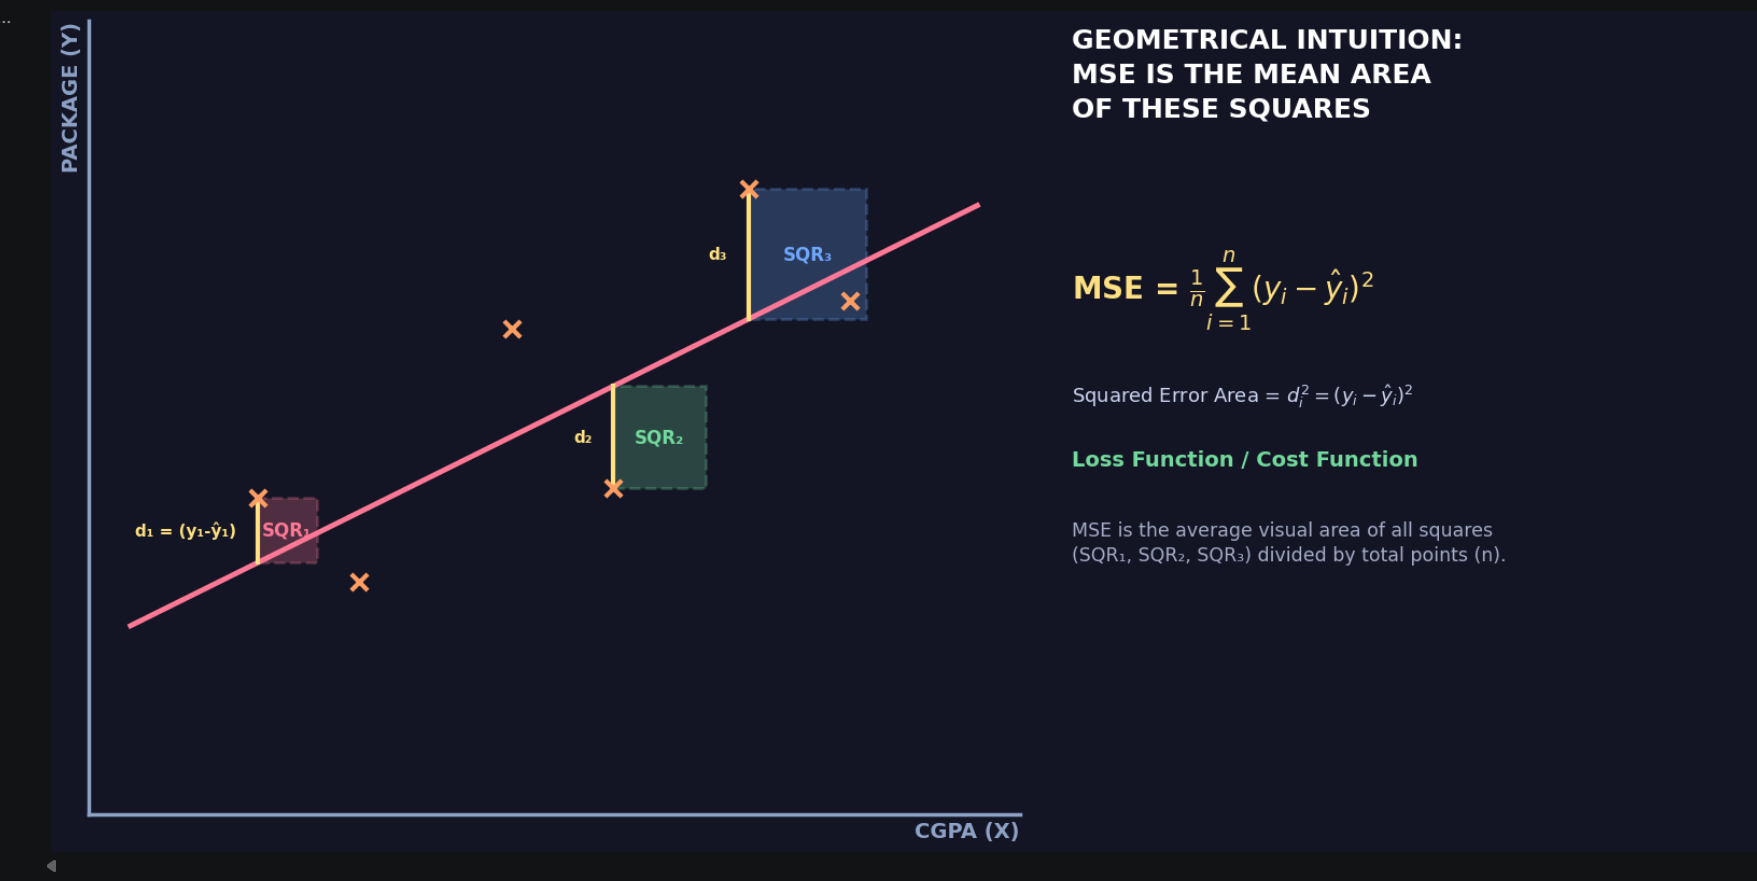

### ***Advantages of MSE***

* **Differentiable:** Square function har point pe smoothly differentiate ho jata hai, isliye formula derive karna aur gradient descent lagana aasan hai.
* **Heavily Penalizes Big Errors:** Error ka square hone se bade errors par bohot zyada penalty lagti hai.



### ***Disadvantages of MSE***

* **Sensitive to Outliers:** Data mein extreme outliers aate hi regression line unki taraf khinch jati hai aur score kharab ho jata hai.
* **Unit Mismatch:** Unit square ho jati hai (jaise **LPA²** ya **₹²**), isliye direct business meaning samajhna mushkil hota hai.

---

## ****3. RMSE (Root Mean Squared Error)****

**Full Form:** Root Mean Squared Error

**Definition:** Root Mean Squared Error (RMSE) simply Mean Squared Error (MSE) ka square root hota hai. Yeh actual values aur predicted values ke squared differences ke mean ka square root nikaal kar overall model ka error batata hai.

---

### ***Formula***

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

---

### ***Properties***

Iski lagbhag saari core properties MSE jaisi hi hoti hain kyunki root lene se pehle andar error ka square hi hota hai:

* Yeh bhi bade errors (outliers) ko heavily penalize karta hai.
* Yeh convex cost landscape follow karta hai.

---

### ***Advantages***

* **Same Unit as Target:** MSE ki tarah iska unit square nahi rehta. Square root lene se unit wapas original scale (jaise **LPA** ya **₹**) par aa jati hai, jisse interpret karna bohot easy ho jata hai.
* **Penalizes Large Errors:** MAE ke comparison mein bade errors ko zyada weight aur penalty deta hai.

---

### ***Disadvantages***

* **Sensitive to Outliers:** MSE ki tarah yeh bhi extreme outliers ke prati sensitive hota hai aur unke aane se score turant bigad jata hai.
* **Mathematical Optimization:** Direct optimization/gradient calculations mein square root ki wajah se chain rule thoda extra complex ho jata hai, isliye training time par log direct MSE choose karte hain.

---

### ***Kahan Use Kiya Jata Hai?***

* **Model Evaluation & Reporting:** Jab aapko model ka final score business stakeholders ko unke original scale/unit (e.g., Salary in Lakhs, House Price in Rupees) mein present karna ho.
* **High-Penalty Domains:** Jahan prediction mein chota-mota error chal sakta hai, lekin bada blunder error bilkul afford nahi kiya ja sakta (jaise share market, high-precision manufacturing, credit risk).

___